This dataset comprises A/B test outcomes for Cookie Cats, investigating the impact of relocating the initial gate in the game from level 30 to level 40. Upon installing the game, players were randomly assigned to either gate_30 or gate_40.

The data we have is from 90,189 players that installed the game while the AB-test was running. The variables are:

userid: A unique number that identifies each player.
version: Whether the player was put in the control group (gate_30 - a gate at level 30) or the group with the moved gate (gate_40 - a gate at level 40).
sum_gamerounds: the number of game rounds played by the player during the first 14 days after install.

retention_1: Did the player come back and play 1 day after installing?
retention_7: Did the player come back and play 7 days after installing?

In [4]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/Users/deepakkushwaha/Library/CloudStorage/GoogleDrive-deepakkushwaha771@gmail.com/My Drive/Data Science/DS Projects/MY Projects/A:B test/cookie_cats.txt')

# Look at the first few rows
print(df.head())

# Check data types and missing values
print(df.info())

   userid  version  sum_gamerounds  retention_1  retention_7
0     116  gate_30               3        False        False
1     337  gate_30              38         True        False
2     377  gate_40             165         True        False
3     483  gate_40               1        False        False
4     488  gate_40             179         True         True
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB
None


In [5]:
# Check for duplicate userids
print(f"Duplicate user IDs: {df['userid'].duplicated().sum()}")

# Check for missing values across all columns
print(df.isnull().sum())

Duplicate user IDs: 0
userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64


In [6]:
# Count the number of players in each group
group_counts = df.groupby('version')['userid'].count()
print(group_counts)

# Quick percentage check
print(group_counts / df['userid'].count())

version
gate_30    44700
gate_40    45489
Name: userid, dtype: int64
version
gate_30    0.495626
gate_40    0.504374
Name: userid, dtype: float64


count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64


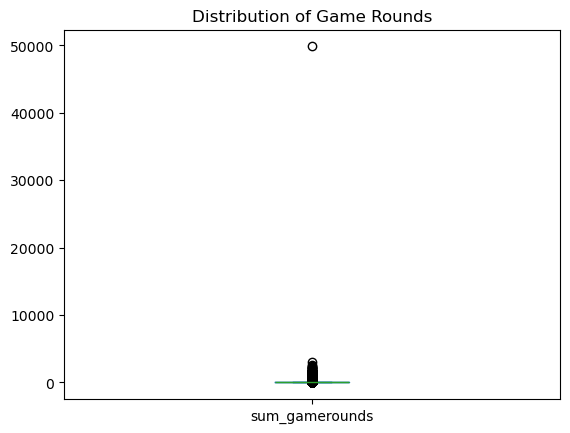

In [7]:
# Summary statistics for game rounds
print(df['sum_gamerounds'].describe())

# Visualizing the distribution to spot extreme outliers
import matplotlib.pyplot as plt

df['sum_gamerounds'].plot.box()
plt.title('Distribution of Game Rounds')
plt.show()

In [8]:
# Keep only the users who played fewer than 40,000 rounds
df = df[df['sum_gamerounds'] < 40000]

# (Optional) You can plot the boxplot again to see a much clearer distribution
# df['sum_gamerounds'].plot.box()
# plt.show()

count    90188.000000
mean        51.320253
std        102.682719
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max       2961.000000
Name: sum_gamerounds, dtype: float64


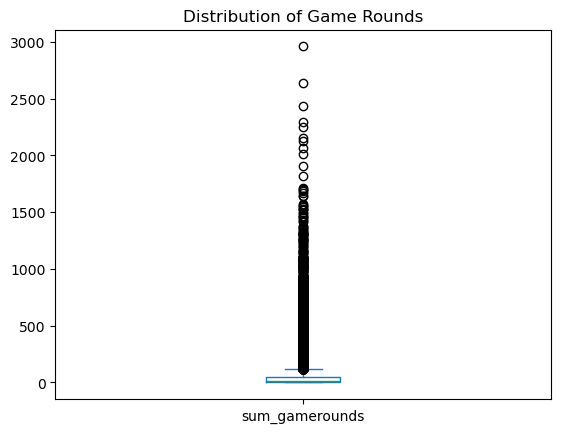

In [9]:
# Summary statistics for game rounds
print(df['sum_gamerounds'].describe())

# Visualizing the distribution to spot extreme outliers
import matplotlib.pyplot as plt

df['sum_gamerounds'].plot.box()
plt.title('Distribution of Game Rounds')
plt.show()

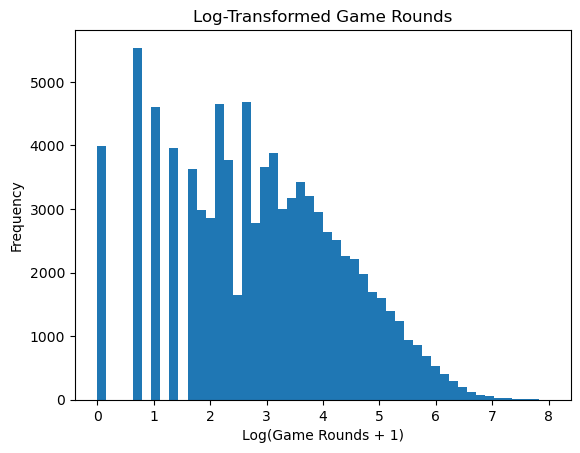

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Apply log(x+1) transform to the game rounds
df['log_gamerounds'] = np.log1p(df['sum_gamerounds'])

# Plot the new transformed distribution
df['log_gamerounds'].plot.hist(bins=50)
plt.title('Log-Transformed Game Rounds')
plt.xlabel('Log(Game Rounds + 1)')
plt.show()

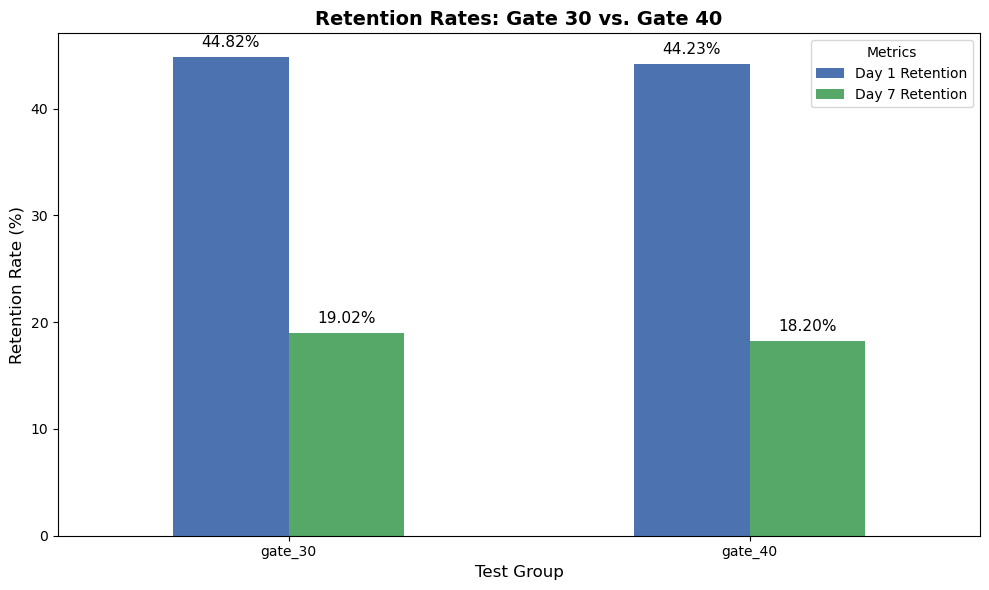

In [11]:
import matplotlib.pyplot as plt

# 1. Calculate the retention rates as percentages
retention_summary = df.groupby('version')[['retention_1', 'retention_7']].mean() * 100

# 2. Create a grouped bar chart
ax = retention_summary.plot(kind='bar', figsize=(10, 6), color=['#4C72B0', '#55A868'])

# 3. Formatting the chart for stakeholders
plt.title('Retention Rates: Gate 30 vs. Gate 40', fontsize=14, fontweight='bold')
plt.ylabel('Retention Rate (%)', fontsize=12)
plt.xlabel('Test Group', fontsize=12)
plt.xticks(rotation=0) # Keeps the x-axis labels horizontal
plt.legend(['Day 1 Retention', 'Day 7 Retention'], title='Metrics')

# 4. Add the exact percentages on top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), 
                textcoords='offset points')

# 5. Display the plot
plt.tight_layout()
plt.show()

In [15]:
import pandas as pd
from scipy.stats import chi2_contingency, mannwhitneyu

# 1. Chi-Square Test for Day 1 Retention
contingency_1 = pd.crosstab(df['version'], df['retention_1'])
chi2_1, p_val_1, dof_1, expected_1 = chi2_contingency(contingency_1)
print(f"Day 1 Retention p-value: {p_val_1:.4f}")

# 2. Chi-Square Test for Day 7 Retention
contingency_7 = pd.crosstab(df['version'], df['retention_7'])
chi2_7, p_val_7, dof_7, expected_7 = chi2_contingency(contingency_7)
print(f"Day 7 Retention p-value: {p_val_7:.4f}")

# 3. Mann-Whitney U Test for Game Rounds
rounds_30 = df[df['version'] == 'gate_30']['sum_gamerounds']
rounds_40 = df[df['version'] == 'gate_40']['sum_gamerounds']
stat, p_val_rounds = mannwhitneyu(rounds_30, rounds_40, alternative='two-sided')
print(f"Game Rounds p-value (Mann-Whitney): {p_val_rounds:.4f}")

Day 1 Retention p-value: 0.0750
Day 7 Retention p-value: 0.0016
Game Rounds p-value (Mann-Whitney): 0.0509


Using a standard statistical significance threshold of 0.05:

Day 1 Retention (p = 0.0750): Not statistically significant. Moving the gate did not definitively change next-day player behavior.

Total Game Rounds (p = 0.0509): Marginal. We cannot confidently claim the gate move altered the total volume of rounds played.

Day 7 Retention (p = 0.0016): Highly statistically significant. Moving the gate to Level 40 definitively caused long-term retention to drop.